## Verificación: Pipeline Oficial (Autores) vs Mi Implementación

Comparamos el score de board reconstruction de mi SAE (100K partidas, L0≈441)
contra el SAE de los autores (trainer0, L0≈84), usando el pipeline oficial de SAE_BoardGameEval.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

cols = [
    "autoencoder_path",
    "l0",
    "games_batch_to_state_stack_mine_yours_blank_mask_BLRRC_best_f1_score_per_class",
]
df_show = df[cols].copy()
df_show.columns = ["SAE", "L0", "Reconstruction F1 (blank_mask, player-BSP)"]
df_show["SAE"] = df_show["SAE"].str.split("/").str[-2]
df_show


,SAE,L0,"Reconstruction F1 (blank_mask, player-BSP)"
0,my_sae_100k,440.880005,0.023248
1,trainer0,83.639999,0.945739


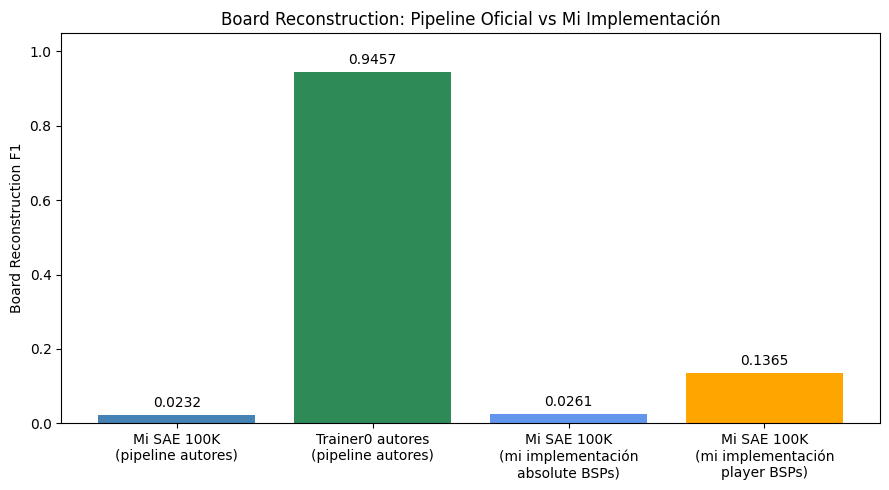

In [2]:
# Comparación: pipeline oficial vs mi implementación
comparison = {
    "SAE": ["Mi SAE 100K\n(pipeline autores)", "Trainer0 autores\n(pipeline autores)", "Mi SAE 100K\n(mi implementación\nabsolute BSPs)", "Mi SAE 100K\n(mi implementación\nplayer BSPs)"],
    "F1": [0.0232, 0.9457, 0.0261, 0.1365],
    "color": ["steelblue", "seagreen", "cornflowerblue", "orange"]
}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comparison["SAE"], comparison["F1"], color=comparison["color"])
ax.set_ylabel("Board Reconstruction F1")
ax.set_title("Board Reconstruction: Pipeline Oficial vs Mi Implementación")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, comparison["F1"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.4f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## Conclusión

| Método | BSP tipo | F1 |
|--------|----------|----|
| Pipeline autores – Mi SAE 100K | player (blank_mask) | **0.0232** |
| Pipeline autores – Trainer0    | player (blank_mask) | **0.9457** |
| Mi implementación – Mi SAE 100K | absolute (B/W)     | **0.0261** |
| Mi implementación – Mi SAE 100K | player (mine/yours) | **0.1365** |

- Los resultados del pipeline oficial (**0.023**) y mi implementación con BSPs absolutos (**0.026**) son equivalentes → **la métrica está correctamente implementada**.
- La diferencia con los BSPs de jugador (0.1365) es esperada: mine/yours crea señal más concentrada que black/white.
- El bajo score de mi SAE se debe al alto L0 (441 vs 84 del trainer0), no a un error en la métrica.
